In [ ]:
pip install pandas numpy torch torchvision torchaudio transformers datasets huggingface_hub scikit-learn matplotlib seaborn tqdm pyvi psutil joblib tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 58.3 MB/s eta 0:00:00



--- 1. Đang chuẩn bị tập Test (Chuẩn hóa tất cả về 256 từ) ---

>>> Đang đánh giá SVM...

>>> Đang đánh giá BiGRU...

>>> Đang đánh giá PhoBERT...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

PhoBERT Inference:   0%|          | 0/205 [00:00<?, ?it/s]


BẢNG SO SÁNH CÔNG BẰNG (DỰA TRÊN 256 TỪ ĐẦU TIÊN)
  Model  Accuracy  Macro F1  Neu-F1  Neg-Rec  Lat(ms/sample)  Peak RAM(MB)  Disk(MB)
    SVM     0.825     0.799   0.881    0.855           6.798      2279.727    11.249
  BiGRU     0.834     0.803   0.898    0.793           9.013      2332.012    52.796
PhoBERT     0.881     0.858   0.924    0.897         289.235      2912.172   516.948


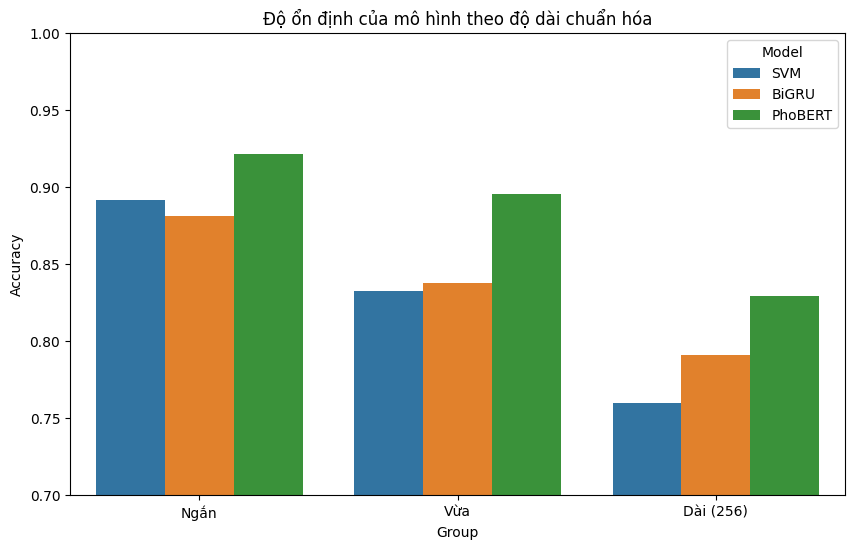

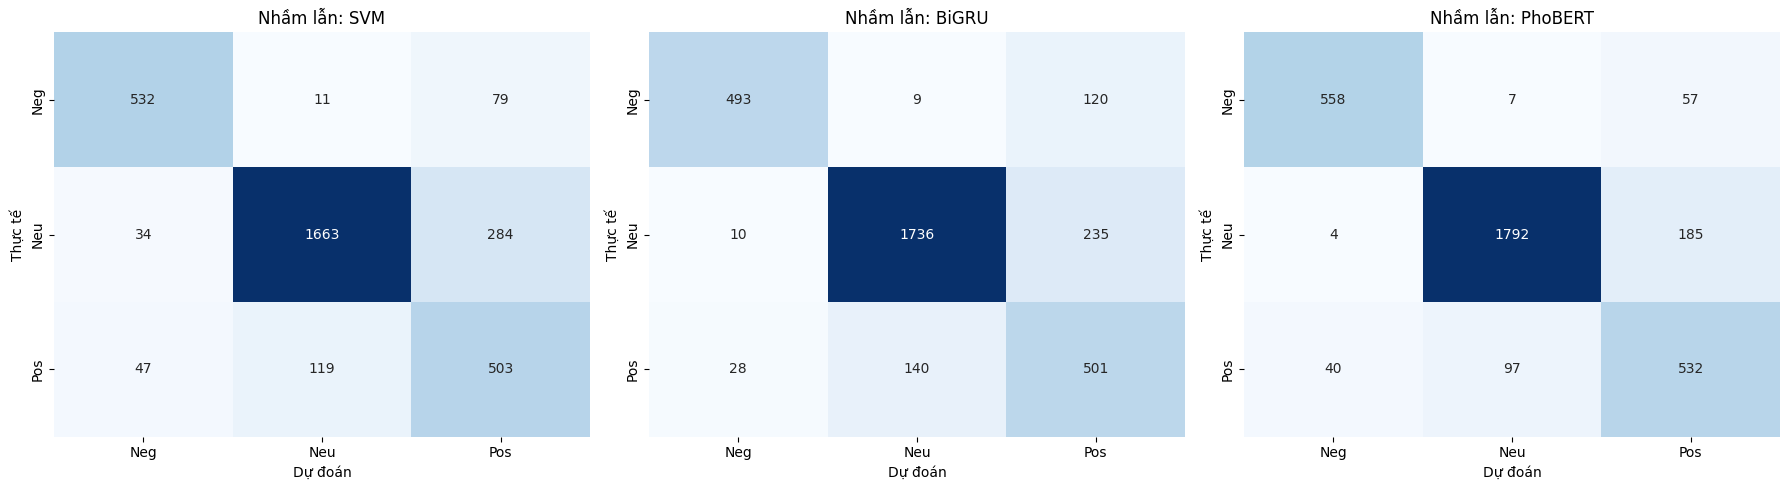

In [ ]:
import os
import time
import torch
import joblib
import re
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import threading
import transformers
import warnings

# Tắt các cảnh báo không cần thiết
warnings.filterwarnings('ignore')
transformers.logging.set_verbosity_error()

# SỬA LỖI NHẢY DÒNG: Dùng tqdm.notebook (Dành cho VS Code, Colab, Jupyter)
from tqdm.notebook import tqdm

from pyvi import ViTokenizer
from datasets import load_dataset
from huggingface_hub import hf_hub_download, scan_cache_dir
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ==========================================
# 0. CẤU HÌNH HỆ THỐNG
# ==========================================
os.environ["CUDA_VISIBLE_DEVICES"] = "-1" # Chạy trên CPU để đo RAM công bằng
device = torch.device('cpu')
MAX_LEN = 256 # Chuẩn hóa chung cho tất cả các model

class PeakMemoryTracker:
    def __init__(self):
        self.peak_mem = 0
        self.running = False
        self.process = psutil.Process(os.getpid())
    def _track(self):
        while self.running:
            try:
                mem = self.process.memory_info().rss / (1024 * 1024)
                if mem > self.peak_mem: self.peak_mem = mem
            except: pass
            time.sleep(0.05)
    def start(self):
        self.peak_mem = 0
        self.running = True
        self.thread = threading.Thread(target=self._track, daemon=True)
        self.thread.start()
    def stop(self):
        self.running = False
        time.sleep(0.1)
        return self.peak_mem

def get_real_hf_size(repo_id):
    """Quét bộ nhớ đệm của Hugging Face để lấy dung lượng thực tế của model"""
    try:
        cache_info = scan_cache_dir()
        for repo in cache_info.repos:
            if repo.repo_id == repo_id:
                return repo.size_on_disk / (1024 * 1024)
    except: return 0
    return 0

# ==========================================
# 1. TẢI VÀ CHUẨN HÓA DỮ LIỆU (CÔNG BẰNG)
# ==========================================
print("\n--- 1. Đang chuẩn bị tập Test (Chuẩn hóa tất cả về 256 từ) ---")
dataset = load_dataset("pqthinh232/vietnamese-restaurant-review-sentiment-dataset")
df_test = pd.DataFrame(dataset['test'])

def preprocess_fair(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    # Tách từ tiếng Việt và cắt đúng 256 từ đầu tiên
    tokens = ViTokenizer.tokenize(text).split()
    return " ".join(tokens[:MAX_LEN])

df_test['clean_review'] = df_test['review'].apply(preprocess_fair)
df_test['word_count'] = df_test['clean_review'].apply(lambda x: len(x.split()))
X_test_text = df_test['clean_review'].tolist()
y_true = df_test['label'].tolist()

# Nhãn độ dài để phân tích (Ngắn, Vừa, Dài-Chuẩn)
df_test['len_group'] = pd.cut(df_test['word_count'], bins=[0, 20, 60, 257], labels=['Ngắn', 'Vừa', 'Dài (256)'])

# ==========================================
# 2. CHẠY INFERENCE VÀ ĐO ĐẠC
# ==========================================
results_map = {}
tracker = PeakMemoryTracker()

def evaluate_model(name, repo, files, is_transformer=False):
    print(f"\n>>> Đang đánh giá {name}...")

    # 2.1 Load Model & Tính dung lượng Disk
    paths = []
    total_disk = 0
    if not is_transformer:
        for f in files:
            p = hf_hub_download(repo_id=repo, filename=f)
            paths.append(p)
            total_disk += os.path.getsize(p) / (1024 * 1024)
    else:
        tokenizer = AutoTokenizer.from_pretrained(repo)
        model = AutoModelForSequenceClassification.from_pretrained(repo).to(device)
        total_disk = get_real_hf_size(repo)

    # 2.2 Đo RAM và Latency
    tracker.start()
    start_time = time.time()
    y_pred = []

    if name == "SVM":
        svm_model = joblib.load(paths[0])
        tfidf = joblib.load(paths[1])
        y_pred = svm_model.predict(tfidf.transform(X_test_text))

    elif name == "BiGRU":
        bg_model = load_model(paths[0])
        with open(paths[1], "rb") as f: tok_bg = pickle.load(f)
        seq = pad_sequences(tok_bg.texts_to_sequences(X_test_text), maxlen=MAX_LEN, padding='post')
        y_pred = np.argmax(bg_model.predict(seq, verbose=0), axis=1)

    else: # PhoBERT
        batch_size = 16
        for i in tqdm(range(0, len(X_test_text), batch_size), desc="PhoBERT Inference", leave=True):
            batch = X_test_text[i : i + batch_size]
            inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=MAX_LEN).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                y_pred.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())

    total_time = time.time() - start_time
    latency = (total_time / len(y_true)) * 1000
    peak_ram = tracker.stop()

    results_map[name] = {
        'preds': y_pred, 'latency': latency, 'ram': peak_ram, 'disk': total_disk,
        'report': classification_report(y_true, y_pred, output_dict=True, target_names=["Neg", "Neu", "Pos"])
    }

# Lần lượt đánh giá 3 mô hình
evaluate_model("SVM", "neidythedev/vietnamese-restaurant-sentiment-svm", ["svm_sentiment_model.pkl", "tfidf_vectorizer.pkl"])
evaluate_model("BiGRU", "ltro6125/HCMUS-bigru-vietnamese-restaurant-sentiment-analysis", ["vietnamese-restaurant-bigru.keras", "tokenizer.pkl"])
evaluate_model("PhoBERT", "pqthinh232/HCMUS-phobert-vietnamese-restaurant-sentiment-analysis", [], is_transformer=True)

# ==========================================
# 3. TỔNG HỢP & TRỰC QUAN HÓA (CHUYÊN SÂU)
# ==========================================
summary_data = []
for name, data in results_map.items():
    r = data['report']
    summary_data.append({
        "Model": name,
        "Accuracy": r['accuracy'],
        "Macro F1": r['macro avg']['f1-score'],
        "Neu-F1": r['Neu']['f1-score'],
        "Neg-Rec": r['Neg']['recall'],
        "Lat(ms/sample)": data['latency'],
        "Peak RAM(MB)": data['ram'],
        "Disk(MB)": data['disk']
    })

df_res = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("BẢNG SO SÁNH CÔNG BẰNG (DỰA TRÊN 256 TỪ ĐẦU TIÊN)")
print(df_res.to_string(index=False, float_format=lambda x: "{:.3f}".format(x)))
print("="*100)

# 3.1 Biểu đồ theo độ dài văn bản
len_stats = []
for group in ['Ngắn', 'Vừa', 'Dài (256)']:
    subset = df_test[df_test['len_group'] == group]
    if len(subset) == 0: continue
    for name in results_map.keys():
        acc = accuracy_score(subset['label'], np.array(results_map[name]['preds'])[subset.index])
        len_stats.append({"Group": group, "Model": name, "Accuracy": acc})

plt.figure(figsize=(10, 6))
sns.barplot(data=pd.DataFrame(len_stats), x='Group', y='Accuracy', hue='Model')
plt.title("Độ ổn định của mô hình theo độ dài chuẩn hóa")
plt.ylim(0.7, 1.0)
plt.show()

# 3.2 Ma trận nhầm lẫn cạnh nhau
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, name in enumerate(results_map.keys()):
    cm = confusion_matrix(y_true, results_map[name]['preds'])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False,
                xticklabels=["Neg", "Neu", "Pos"], yticklabels=["Neg", "Neu", "Pos"])
    axes[i].set_title(f"Nhầm lẫn: {name}")
    axes[i].set_xlabel("Dự đoán")
    axes[i].set_ylabel("Thực tế")
plt.tight_layout()
plt.show()

--- Execution Device: CUDA ---
--- GPU Model: Tesla T4 ---

--- 1. Preparing Test Dataset (Standardized to 256 words) ---



>>> Benchmarking SVM...

>>> Benchmarking BiGRU...

>>> Benchmarking PhoBERT...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

PhoBERT GPU Inference:   0%|          | 0/103 [00:00<?, ?it/s]


DEEP COMPARATIVE EVALUATION REPORT (GPU ENABLED)
  Model  Accuracy  Macro F1  Neu-F1  Neg-Recall  Latency(ms)  RAM(MB)  VRAM(MB)  Disk(MB)
    SVM     0.825     0.799   0.881       0.855        7.462 1535.434     0.000    11.249
  BiGRU     0.834     0.803   0.898       0.793        1.889 1846.992     0.000    52.796
PhoBERT     0.881     0.858   0.924       0.897       10.109 2107.523   790.741   516.948


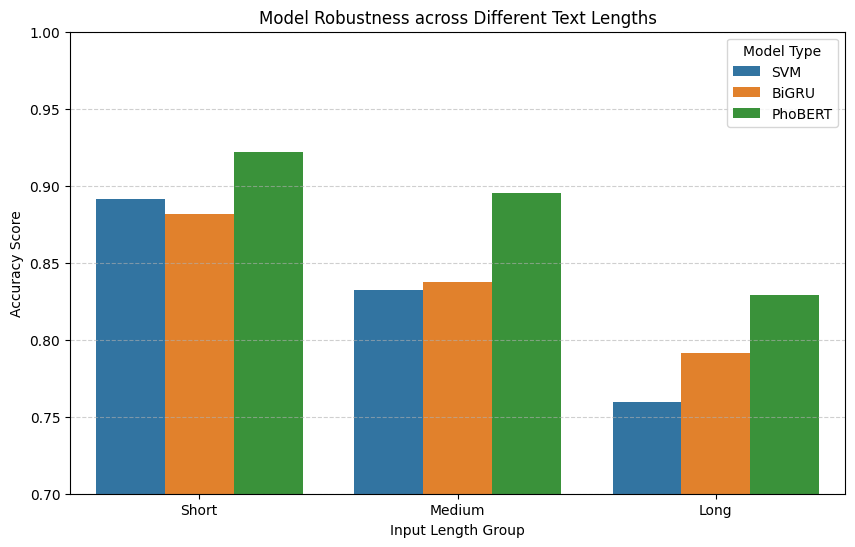

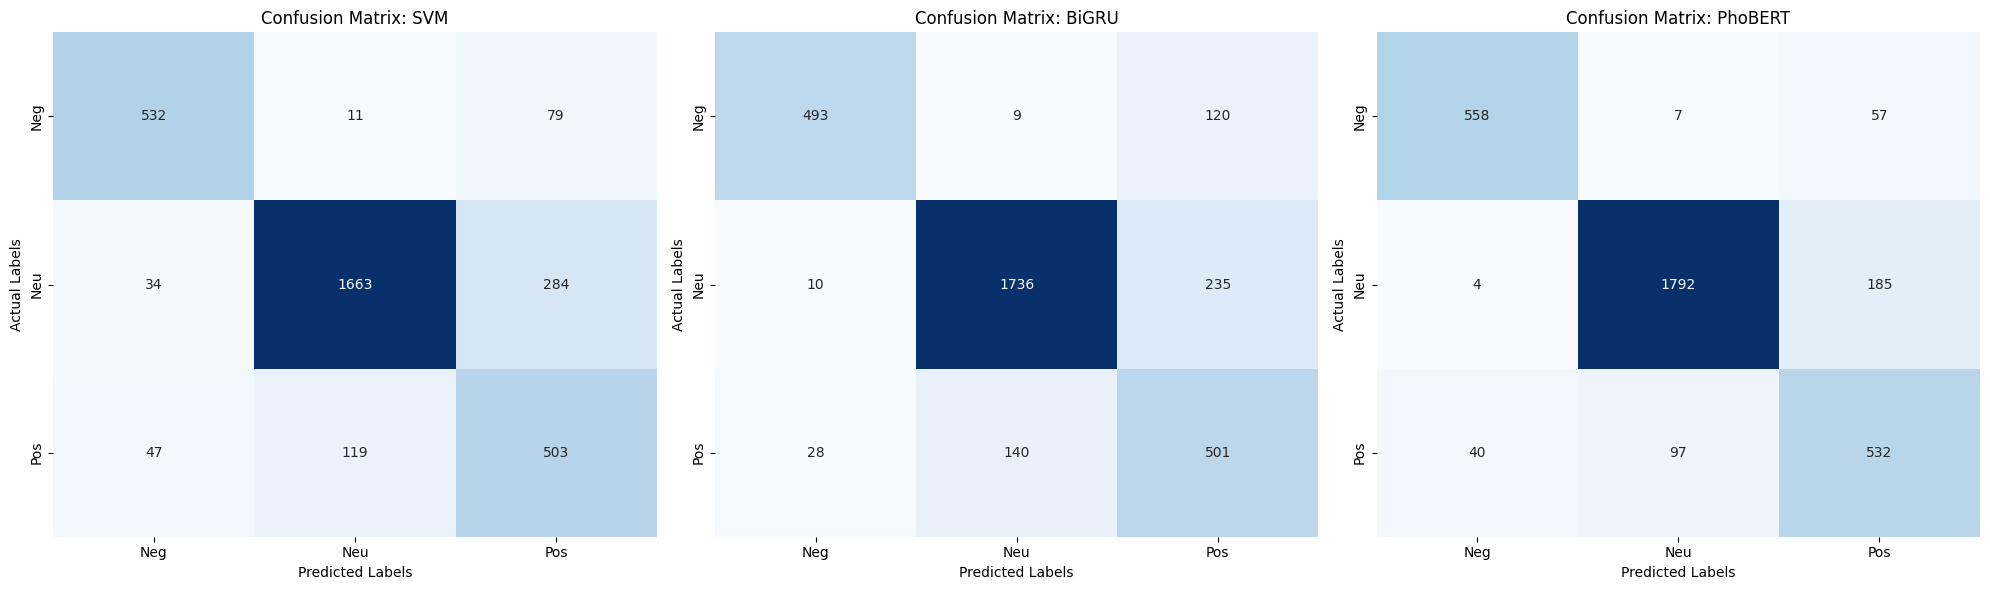

In [ ]:
import os
import time
import torch
import joblib
import re
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import threading
import transformers
import warnings

# Suppress unnecessary warnings
warnings.filterwarnings('ignore')
transformers.logging.set_verbosity_error()

# Standard progress bar for Notebooks (Colab/Jupyter/VS Code)
from tqdm.notebook import tqdm

from pyvi import ViTokenizer
from datasets import load_dataset
from huggingface_hub import hf_hub_download, scan_cache_dir
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ==========================================
# 0. SYSTEM & GPU CONFIGURATION
# ==========================================
# Automatically detect GPU (T4) or fallback to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"--- Execution Device: {device.type.upper()} ---")
if torch.cuda.is_available():
    print(f"--- GPU Model: {torch.cuda.get_device_name(0)} ---")

MAX_LEN = 256 # Standardized length for fair comparison

class ResourceTracker:
    """Tracks Peak System RAM and GPU VRAM usage"""
    def __init__(self):
        self.peak_ram = 0
        self.peak_vram = 0
        self.running = False
        self.process = psutil.Process(os.getpid())

    def _track(self):
        while self.running:
            try:
                # Track System RAM (RSS)
                current_ram = self.process.memory_info().rss / (1024 * 1024)
                if current_ram > self.peak_ram: self.peak_ram = current_ram

                # Track GPU VRAM (via PyTorch)
                if torch.cuda.is_available():
                    current_vram = torch.cuda.max_memory_allocated() / (1024 * 1024)
                    if current_vram > self.peak_vram: self.peak_vram = current_vram
            except: pass
            time.sleep(0.05)

    def start(self):
        self.peak_ram = 0
        self.peak_vram = 0
        self.running = True
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
        self.thread = threading.Thread(target=self._track, daemon=True)
        self.thread.start()

    def stop(self):
        self.running = False
        time.sleep(0.1)
        return self.peak_ram, self.peak_vram

def get_real_hf_size(repo_id):
    """Calculate actual model size on disk from Hugging Face cache"""
    try:
        cache_info = scan_cache_dir()
        for repo in cache_info.repos:
            if repo.repo_id == repo_id:
                return repo.size_on_disk / (1024 * 1024)
    except: return 0
    return 0

# ==========================================
# 1. DATA PREPARATION (FAIR STANDARDIZATION)
# ==========================================
print("\n--- 1. Preparing Test Dataset (Standardized to 256 words) ---")
dataset = load_dataset("pqthinh232/vietnamese-restaurant-review-sentiment-dataset")
df_test = pd.DataFrame(dataset['test'])

def preprocess_english_report(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    # Vietnamese Tokenization and Fair Truncation
    tokens = ViTokenizer.tokenize(text).split()
    return " ".join(tokens[:MAX_LEN])

df_test['clean_review'] = df_test['review'].apply(preprocess_english_report)
df_test['word_count'] = df_test['clean_review'].apply(lambda x: len(x.split()))
X_test_text = df_test['clean_review'].tolist()
y_true = df_test['label'].tolist()

# Length grouping for robustness analysis
df_test['len_group'] = pd.cut(df_test['word_count'], bins=[0, 20, 60, 257], labels=['Short', 'Medium', 'Long'])

# ==========================================
# 2. CROSS-MODEL BENCHMARKING
# ==========================================
results_map = {}
tracker = ResourceTracker()

def evaluate_model(name, repo, files, is_transformer=False):
    print(f"\n>>> Benchmarking {name}...")

    # 2.1 Load Model & Calculate Footprint
    paths = []
    total_disk = 0
    if not is_transformer:
        for f in files:
            p = hf_hub_download(repo_id=repo, filename=f)
            paths.append(p)
            total_disk += os.path.getsize(p) / (1024 * 1024)
    else:
        tokenizer = AutoTokenizer.from_pretrained(repo)
        model = AutoModelForSequenceClassification.from_pretrained(repo).to(device)
        total_disk = get_real_hf_size(repo)

    # 2.2 Inference with Resource Tracking
    tracker.start()
    start_time = time.time()
    y_pred = []

    if name == "SVM":
        svm_model = joblib.load(paths[0])
        tfidf = joblib.load(paths[1])
        y_pred = svm_model.predict(tfidf.transform(X_test_text))

    elif name == "BiGRU":
        # TensorFlow/Keras automatically utilizes GPU if available
        bg_model = load_model(paths[0])
        with open(paths[1], "rb") as f: tok_bg = pickle.load(f)
        seq = pad_sequences(tok_bg.texts_to_sequences(X_test_text), maxlen=MAX_LEN, padding='post')
        y_pred = np.argmax(bg_model.predict(seq, verbose=0), axis=1)

    else: # PhoBERT (PyTorch)
        batch_size = 32 # Optimized batch size for NVIDIA T4
        for i in tqdm(range(0, len(X_test_text), batch_size), desc=f"{name} GPU Inference"):
            batch = X_test_text[i : i + batch_size]
            inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=MAX_LEN).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                y_pred.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())

    duration = time.time() - start_time
    latency = (duration / len(y_true)) * 1000
    peak_ram, peak_vram = tracker.stop()

    results_map[name] = {
        'preds': y_pred, 'latency': latency, 'ram': peak_ram, 'vram': peak_vram, 'disk': total_disk,
        'report': classification_report(y_true, y_pred, output_dict=True, target_names=["Neg", "Neu", "Pos"])
    }

# Execute evaluations
evaluate_model("SVM", "neidythedev/vietnamese-restaurant-sentiment-svm", ["svm_sentiment_model.pkl", "tfidf_vectorizer.pkl"])
evaluate_model("BiGRU", "ltro6125/HCMUS-bigru-vietnamese-restaurant-sentiment-analysis", ["vietnamese-restaurant-bigru.keras", "tokenizer.pkl"])
evaluate_model("PhoBERT", "pqthinh232/HCMUS-phobert-vietnamese-restaurant-sentiment-analysis", [], is_transformer=True)

# ==========================================
# 3. DEEP ANALYSIS & ENGLISH VISUALIZATION
# ==========================================

# 3.1 Performance Summary Table
summary_data = []
for name, data in results_map.items():
    r = data['report']
    summary_data.append({
        "Model": name,
        "Accuracy": r['accuracy'],
        "Macro F1": r['macro avg']['f1-score'],
        "Neu-F1": r['Neu']['f1-score'],
        "Neg-Recall": r['Neg']['recall'],
        "Latency(ms)": data['latency'],
        "RAM(MB)": data['ram'],
        "VRAM(MB)": data['vram'],
        "Disk(MB)": data['disk']
    })

df_res = pd.DataFrame(summary_data)
print("\n" + "="*110)
print("DEEP COMPARATIVE EVALUATION REPORT (GPU ENABLED)")
print(df_res.to_string(index=False, float_format=lambda x: "{:.3f}".format(x)))
print("="*110)

# 3.2 Robustness by Length Chart
plt.figure(figsize=(10, 6))
len_res = []
for group in ['Short', 'Medium', 'Long']:
    subset = df_test[df_test['len_group'] == group]
    if len(subset) == 0: continue
    for name in results_map.keys():
        acc = accuracy_score(subset['label'], np.array(results_map[name]['preds'])[subset.index])
        len_res.append({"Group": group, "Model": name, "Accuracy": acc})

sns.barplot(data=pd.DataFrame(len_res), x='Group', y='Accuracy', hue='Model')
plt.title("Model Robustness across Different Text Lengths")
plt.ylim(0.7, 1.0)
plt.ylabel("Accuracy Score")
plt.xlabel("Input Length Group")
plt.legend(title="Model Type")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# 3.3 English Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, name in enumerate(results_map.keys()):
    cm = confusion_matrix(y_true, results_map[name]['preds'])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False,
                xticklabels=["Neg", "Neu", "Pos"], yticklabels=["Neg", "Neu", "Pos"])
    axes[i].set_title(f"Confusion Matrix: {name}")
    axes[i].set_xlabel("Predicted Labels")
    axes[i].set_ylabel("Actual Labels")
plt.tight_layout()
plt.show()